In [ ]:
from hardDisks import dynamicHardDisks, staticHardDisks, hardDiskTrajectory
from molsim import HardDisks
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.patches import Circle
from matplotlib.animation import FuncAnimation
import numba

<div style="max-width: 1000px; margin-left: 0; margin-right: auto; font-size: 20px; line-height: 1.6;">

# Exercise 2: Hard disks in a square

Consider a system of $N$ identical hard disks with diameter $1$ in a
square of size $10$. The use of periodic boundary conditions can be
switched on or off. The energy of this system ($U$) is either $U=0$ 
(no overlaps) or $U=\infty$ (at least one overlap). We would like to calculate the
radial distribution function of the disks ($g\left(r\right), \,\,r <
5$) in the canonical ensemble. There are 2 methods of calculating
this:
### 1. Dynamic scheme
The disks are initially placed on a lattice
and trial moves are performed to translate the disks. A trial move is
accepted when there are no overlaps and rejected when there are one or
more overlaps.
<div style="max-width:300px;margin-right: auto; margin-right: 0;">

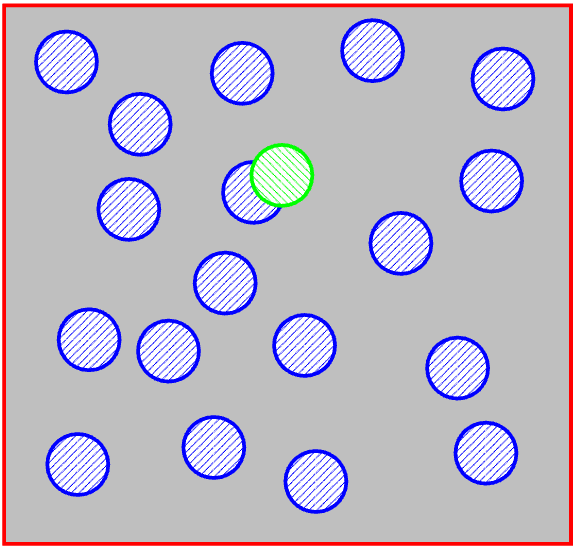
</div>


### 2. Static scheme
In every cycle, all disks are put at a
completely random position in the system. The radial distribution
function of this configuration is calculated and multiplied by the
Boltzmann factor of the system ($0$ when there is at least one overlap
and $1$ when there are no overlaps).
<div style="max-width:300px;margin-right: auto; margin-right: 0;">

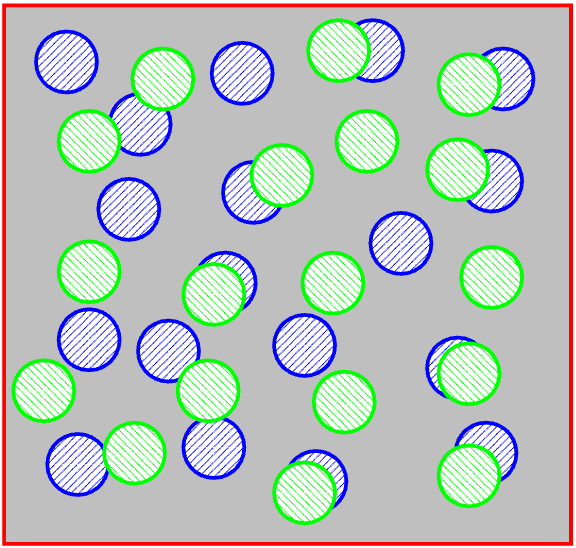
</div>

**Figures:** Eighteen hard disks in a box. The blue particles constitute the old system,
 the green particles the new system. The dynamic scheme performs a displacement trial move
 in one of the particles. The move is rejected when there is a overlap. The static scheme puts all
 particles at new random positions in the system. The move is accepted when there is no overlap.

## Periodic boundary conditions
In the Random Walk exercise from yesterday you already had a look at periodic boundary conditions. 
Periodic boundary conditions (PBCs) mimic an infinite system by tiling the simulation box with 
identical copies of itself. In a L by L box, particles leaving one side re-enter from the opposite 
side, ensuring continuity. Interactions are calculated using the minimum image convention, where 
each particle interacts with the closest image of other particles, considering the periodic replicas. 
This eliminates edge effects, making the finite system behave like an infinite one.

</div>

<div style="max-width: 1000px; margin-left: 0; margin-right: auto; font-size: 20px; line-height: 1.6;">

### Question 1:
Look at the code in ```molsim.hardDisks.py``` in the Python code where the dynamic (```dynamicHardDisks```) Monte Carlo scheme is implemented. 
Your task is to complete the functions ```checkOverlapParticles```, ```checkOverlapWalls``` and ```lowerTriangularDistMatrix``` for both cases: 
with and without periodic boundary conditions (PBC).

For hard disks:
- ***With PBC***: A particle can move outside the simulation box. This movement is treated as though it enters from 
the opposite side, effectively wrapping around the box. You must ensure that the particle does not overlap 
with any other particles or their periodic images after the move.
- ***Without PBC***: Particles are confined within the box. A move is only valid if the particle stays entirely 
within the box boundaries and does not overlap with any other particle.

First we will work on completing the ```checkOverlapParticles``` and ```checkOverlapWalls``` functions. If implemented correctly the visualization bellow 
should show no overlap and depending on wether PBC are applied stay within or move beyond the box. The disk diameter 
is 1 $\sigma$ and box size is in units of $\sigma$.
You can modify the $\texttt{boxSize}$ or $\texttt{numberOfParticles}$ to visualy see how the density changes the MC moves performed and acceptance in the scheme.

In the visualization, the red disk represents the particle being considered for the Monte Carlo move. If the move is rejected, the disk becomes fully red.
</div>

In [ ]:
boxSize = 10.0  # in units size sigma
periodicBoundary = True

# Run the simulation
_, positionsDynamicPbcTrue, _, acceptedMoveDynamicPbcTrue = dynamicHardDisks(
    numberOfInitCycles=int(1e6),
    numberOfProdCycles=int(100),
    numberOfParticles=32,
    maxDisplacement=0.5,
    sampleFrequency=1,
    boxSize=boxSize,
    rdfBins=100,
    periodicBoundary=periodicBoundary,
)

# Plot the trajectory
hardDiskTrajectory(
    positionsDynamicPbcTrue, acceptedMoveDynamicPbcTrue, boxSize, periodicBoundary=periodicBoundary, dynamic=True
)

In [ ]:
periodicBoundary = False

# Run the simulation
_, positionsDynamicPbcFalse, _, acceptedMoveDynamicPbcFalse = dynamicHardDisks(
    numberOfInitCycles=int(1e6),
    numberOfProdCycles=int(100),
    numberOfParticles=32,
    maxDisplacement=0.5,
    sampleFrequency=1,
    boxSize=boxSize,
    rdfBins=100,
    periodicBoundary=periodicBoundary,
)

# Plot the trajectory
hardDiskTrajectory(
    positionsDynamicPbcFalse, acceptedMoveDynamicPbcFalse, boxSize, periodicBoundary=periodicBoundary, dynamic=True
)

<div style="max-width: 1000px; margin-left: 0; margin-right: auto; font-size: 20px; line-height: 1.6;">

## Question 2:
With the implemented `checkOverlapParticles` and `checkOverlapWalls` functions, the static scheme implemented in `staticHardDisks` is now also functional. 
Compare the animations above with those shown below. What differences do you observe in the acceptance rates? Can both methods operate effectively at the 
same density? How much does the system change over the 100 Monte Carlo steps displayed below?

</div>

In [ ]:
boxSize = 10.0
periodicBoundary = True

# Run the simulation
_, positionsStaticPbcTrue, _ = staticHardDisks(
    numberOfInitCycles=int(1e6),
    numberOfProdCycles=int(100),
    numberOfParticles=16,
    maxDisplacement=0.5,
    sampleFrequency=1,
    boxSize=boxSize,
    rdfBins=100,
    periodicBoundary=periodicBoundary,
)

# Plot the trajectory
hardDiskTrajectory(positionsStaticPbcTrue, None, boxSize, periodicBoundary=periodicBoundary, dynamic=False)

In [ ]:
boxSize = 20.0
periodicBoundary = False

# Run the simulation
_, positionsStaticPbcFalse, _ = staticHardDisks(
    numberOfInitCycles=int(1e6),
    numberOfProdCycles=int(100),
    numberOfParticles=16,
    maxDisplacement=0.5,
    sampleFrequency=1,
    boxSize=boxSize,
    rdfBins=100,
    periodicBoundary=periodicBoundary,
)

# Plot the trajectory
hardDiskTrajectory(positionsStaticPbcFalse, None, boxSize, periodicBoundary=periodicBoundary, dynamic=False)

<div style="max-width: 1000px; margin-left: 0; margin-right: auto; font-size: 20px; line-height: 1.6;">

## Question 3:
Next, we will focus on calculating the radial distribution function $g(r)$. Your task is to complete the `lowerTriangularDistMatrix` 
function so that it works with periodic boundary conditions. This function computes the pairwise distances between particles and 
returns a **lower triangular distance matrix**, which avoids redundant calculations.
It outputs a 1D array containing the pairwise distances in the lower triangular part of the distance matrix (excluding the diagonal). 
The length of the array is 0.5 * numberOfParticles * (numberOfParticles - 1).

Additionally, determine and implement the appropriate normalization required for radial averaging in the `normalizeRdf` function.
Radial averaging is needed to account for the increasing area of radial shells at larger distances, ensuring the radial distribution 
function $g(r)$ reflects the true particle density without geometric bias.

Below, a production Monte Carlo (MC) run is performed with \( 10^7 \) MC cycles, saving every 1000th MC move.  
Ensure that both the static and dynamic schemes produce the same results when the `numberOfParticles` is small.

</div>

In [ ]:
boxSize = 10.0
numberOfParticles = 16
periodicBoundary = True

# Run the simulation
_, _, rdfDynamicPbcTrue, _ = dynamicHardDisks(
    numberOfInitCycles=int(1e6),
    numberOfProdCycles=int(1e7),
    numberOfParticles=numberOfParticles,
    maxDisplacement=0.5,
    sampleFrequency=1000,
    boxSize=boxSize,
    rdfBins=100,
    periodicBoundary=periodicBoundary,
)

# Run the simulation
_, _, rdfStaticPbcTrue = staticHardDisks(
    numberOfInitCycles=int(1e6),
    numberOfProdCycles=int(1e7),
    numberOfParticles=numberOfParticles,
    maxDisplacement=0.5,
    sampleFrequency=1000,
    boxSize=boxSize,
    rdfBins=100,
    periodicBoundary=periodicBoundary,
)

# Plot the radial distribution function
plt.figure()
plt.plot(rdfStaticPbcTrue[0], rdfStaticPbcTrue[1], label="static")
plt.plot(rdfDynamicPbcTrue[0], rdfDynamicPbcTrue[1], label="dynamic")
plt.legend()
plt.xlabel(r"Distance r / $\sigma$")
plt.ylabel(r"RDF $g(r/)$")
plt.title(rf"Radial distribution function at a density $\rho=$ {numberOfParticles/(boxSize**2)} " + r"[$\sigma^{-2}]$")

<div style="max-width: 1000px; margin-left: 0; margin-right: auto; font-size: 20px; line-height: 1.6;">

Also, compare the effect of turning periodic boundary conditions off when calculating the radial distribution function $g(r)$. 
If the implementation is correct, $g(r)$ will approach 1 for larger $r$ with periodic boundaries, while it will decay when 
periodic boundaries are not used. This analysis will be performed only for the dynamic scheme.
<div style="max-width:500px;margin-right: auto; margin-right: 0;">

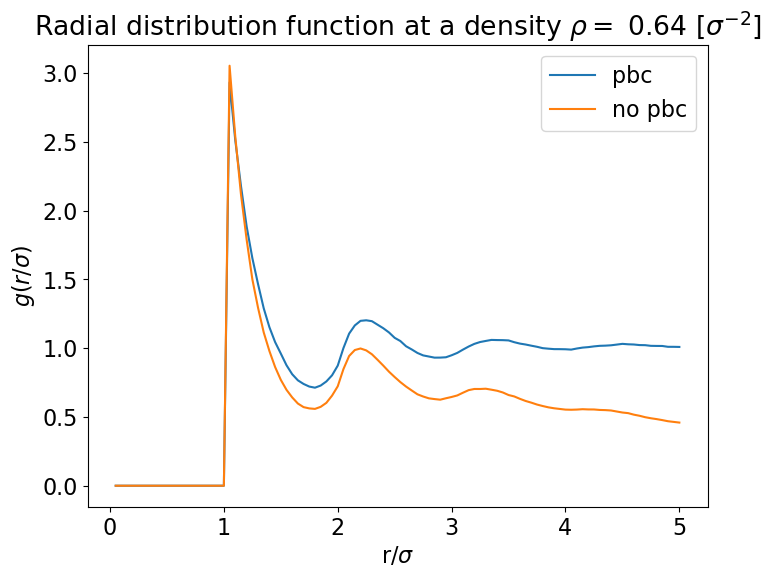

</div>




In [ ]:
boxSize = 10.0
numberOfParticles = 16
periodicBoundary = True

# Run the simulation
_, _, rdfDynamicPbcTrue, _ = dynamicHardDisks(
    numberOfInitCycles=int(1e6),
    numberOfProdCycles=int(1e7),
    numberOfParticles=numberOfParticles,
    maxDisplacement=0.5,
    sampleFrequency=1000,
    boxSize=boxSize,
    rdfBins=100,
    periodicBoundary=periodicBoundary,
)

periodicBoundary = False

# Run the simulation
_, _, rdfDynamicPbcFalse, _ = dynamicHardDisks(
    numberOfInitCycles=int(1e6),
    numberOfProdCycles=int(1e7),
    numberOfParticles=numberOfParticles,
    maxDisplacement=0.5,
    sampleFrequency=1000,
    boxSize=boxSize,
    rdfBins=100,
    periodicBoundary=periodicBoundary,
)

In [ ]:
# Plot the radial distribution function
plt.figure()
plt.plot(rdfDynamicPbcTrue[0], rdfDynamicPbcTrue[1], label="pbc")
plt.plot(rdfDynamicPbcFalse[0], rdfDynamicPbcFalse[1], label="no pbc")
plt.legend()
plt.xlabel(r"Distance r / $\sigma$")
plt.ylabel(r"RDF $g(r/)$")
plt.title(rf"Radial distribution function at a density $\rho=$ {numberOfParticles/(boxSize**2)} " + r"[$\sigma^{-2}]$")

<div style="max-width: 1000px; margin-left: 0; margin-right: auto; font-size: 20px; line-height: 1.6;">

## Question 4:

At which density does the static method start to fail. Plot the acceptance ratio for both the methods at different densities. 
We will perform this analysis with periodic boundary conditions turned on.

In [ ]:
# Define parameters
numberOfParticles = 16
periodicBoundary = True
numberOfInitCycles = int(1e6)
numberOfProdCycles = int(1e6)
maxDisplacement = 0.5
sampleFrequency = 1000
rdfBins = 100

# Define box sizes to vary density
# start refactor
box_sizes = None
# end refactor

# Initialize lists to store results
acceptanceRatiosStatic = []
acceptanceRatiosDynamic = []
rdfsStatic = []
rdfsDynamic = []

# Loop over box sizes
for boxSize in box_sizes:
    # Perform dynamic Monte Carlo simulation
    print("Box size:", boxSize)

    # Perform dynamic Monte Carlo simulation
    acceptanceRatioDynamic, _, rdfDynamic, _ = dynamicHardDisks(
        numberOfInitCycles=numberOfInitCycles,
        numberOfProdCycles=numberOfProdCycles,
        numberOfParticles=numberOfParticles,
        maxDisplacement=maxDisplacement,
        sampleFrequency=sampleFrequency,
        boxSize=boxSize,
        rdfBins=rdfBins,
        periodicBoundary=periodicBoundary,
    )

    # Perform static Monte Carlo simulation
    acceptanceRatioStatic, _, rdfStatic = staticHardDisks(
        numberOfInitCycles=numberOfInitCycles,
        numberOfProdCycles=numberOfProdCycles,
        numberOfParticles=numberOfParticles,
        maxDisplacement=maxDisplacement,
        sampleFrequency=sampleFrequency,
        boxSize=boxSize,
        rdfBins=rdfBins,
        periodicBoundary=periodicBoundary,
    )

    # Store acceptance ratios
    acceptanceRatiosDynamic.append(acceptanceRatioDynamic)
    acceptanceRatiosStatic.append(acceptanceRatioStatic)

    # Store RDFs
    rdfsDynamic.append(rdfDynamic)
    rdfsStatic.append(rdfStatic)

In [ ]:
# Plot acceptance ratios
plt.figure(figsize=(8, 6))
density = numberOfParticles / np.square(box_sizes)
plt.plot(density, acceptanceRatiosStatic, label="Static MC", marker="o")
plt.plot(density, acceptanceRatiosDynamic, label="Dynamic MC", marker="o")
plt.xlabel("Density")
plt.ylabel("Acceptance Ratio")
plt.title("Acceptance Ratio vs density")
plt.legend()
plt.grid()
plt.show()

# Plot RDFs for different box sizes
# Determine number of rows and columns for subplots
num_plots = len(box_sizes)
cols = min([3, num_plots])  # Maximum of 3 columns for better readability
rows = math.ceil(num_plots / cols)

# Create subplots with a flexible grid layout
fig, ax = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
ax = ax.flatten()
fig.suptitle("Radial Distribution Function (RDF) for different densities", fontsize=16, y=1.02)

for i, boxSize in enumerate(box_sizes):
    ax[i].plot(rdfsStatic[i][0], rdfsStatic[i][1], label="Static MC RDF")
    ax[i].plot(rdfsDynamic[i][0], rdfsDynamic[i][1], label="Dynamic MC RDF")
    ax[i].set_xlabel(r"r/$\sigma$")
    ax[i].set_ylabel(r"$g(r/\sigma)$")
    ax[i].set_title(rf"$\rho = {np.round(density[i], 2)} \, [\sigma^{-2}]$")
    ax[i].set_ylim([0, np.max(rdfsDynamic[i][1]) * 1.3])
    ax[i].legend()
    ax[i].grid()
# Hide unused subplots if any
for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])
fig.tight_layout()

<div style="max-width: 1000px; margin-left: 0; margin-right: auto; font-size: 20px; line-height: 1.6;">

### Question 5:
For which method is there a stronger correlation between successive elements of the Markov chain? Explain your reasoning.
</div>

<div style="max-width: 1000px; margin-left: 0; margin-right: auto; font-size: 20px; line-height: 1.6;">


The Hard Disk Monte Carlo simulations in this notebook were performed using the Python code `HardDisks.py` in the `molsim` module 
folder. Within the `molsim` module, an alternative version of the Python implementation has been created using C++ with `pybind11`. 
In the notebook `HardDisksBenchmark.ipynb`, we will analyze and compare the computational efficiency between Python, Python with 
Just-In-Time compilation (`numba.njit`), and C++ code integrated into a Python module via `pybind11`.
